# Imports

In [1]:
!pip install torchinfo

In [2]:
import torch
import torchvision
from torchvision.models import resnet18, densenet121, vgg16, mobilenet_v3_large
from torchvision.transforms import v2
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
from google.colab import drive
import os

drive.mount('/content/drive')

default_notebook_path = '/content/drive/MyDrive/Kristiania/5th_Semester/Deep_Learning/Mandatory_Assignment'
if os.path.exists(default_notebook_path):
    cifar10data = os.path.join(default_notebook_path, 'cifar10_data')
else:
    cifar10data = '/content/drive/MyDrive/Kristiania/5th_Semester/Deep_Learning/Mandatory_Assignment/cifar10_data'

os.makedirs(cifar10data, exist_ok=True)
print(f"CIFAR-10 datasets will be saved/loaded from: {cifar10data}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CIFAR-10 datasets will be saved/loaded from: /content/drive/MyDrive/Kristiania/5th_Semester/Deep_Learning/Mandatory_Assignment/cifar10_data


# Defining Three Architectures

In [5]:
# (I'll remove name later)
# Note: Baseline
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),
            nn.Conv2d(64, 140, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(140 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def get_cifar_mobilenet_v3():
    model = mobilenet_v3_large(weights=None, num_classes=10)
    # Adapt for 32x32 CIFAR-10 inputs (reduce first stride to prevent downsampling the resolution too quickly)
    model.features[0][0] = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
    return model

def get_cifar_densenet121():
    model = densenet121(weights=None, num_classes=10)
    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)   # Modify the first convolutional layer and pooling for 32x32 inputs
    model.features.pool0 = nn.Identity()
    return model

architectures = {
    "baseline_simple_cnn": SimpleCNN,
    "mobilenet_v3": get_cifar_mobilenet_v3,
    "densenet121": get_cifar_densenet121
}

In [6]:
from torchinfo import summary

# Vi lager midlertidige instanser av modellene for å visualisere dem med en typisk batchstørrelse på 64 og bildestørrelse 32x32
print("=== SimpleCNN Summary ===")
simple_cnn = SimpleCNN()
print(summary(simple_cnn, input_size=(64, 3, 32, 32)))

print("\n=== MobileNetV3 Summary ===")
mobilenet_model = get_cifar_mobilenet_v3()
print(summary(mobilenet_model, input_size=(64, 3, 32, 32)))

print("\n=== DenseNet121 Summary ===")
densenet_model = get_cifar_densenet121()
print(summary(densenet_model, input_size=(64, 3, 32, 32)))

=== SimpleCNN Summary ===
Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [64, 10]                  --
├─Sequential: 1-1                        [64, 140, 8, 8]           --
│    └─Conv2d: 2-1                       [64, 32, 32, 32]          896
│    └─LeakyReLU: 2-2                    [64, 32, 32, 32]          --
│    └─Conv2d: 2-3                       [64, 32, 32, 32]          9,248
│    └─LeakyReLU: 2-4                    [64, 32, 32, 32]          --
│    └─Conv2d: 2-5                       [64, 64, 32, 32]          18,496
│    └─ReLU: 2-6                         [64, 64, 32, 32]          --
│    └─MaxPool2d: 2-7                    [64, 64, 16, 16]          --
│    └─Dropout2d: 2-8                    [64, 64, 16, 16]          --
│    └─Conv2d: 2-9                       [64, 140, 16, 16]         80,780
│    └─ReLU: 2-10                        [64, 140, 16, 16]         --
│    └─MaxPool2d: 2-11                   [64, 1

# Defining Three Augmentations

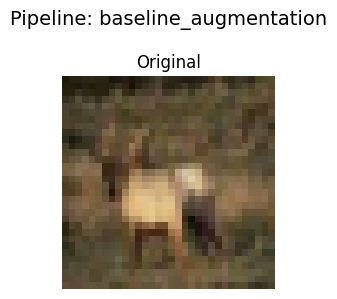

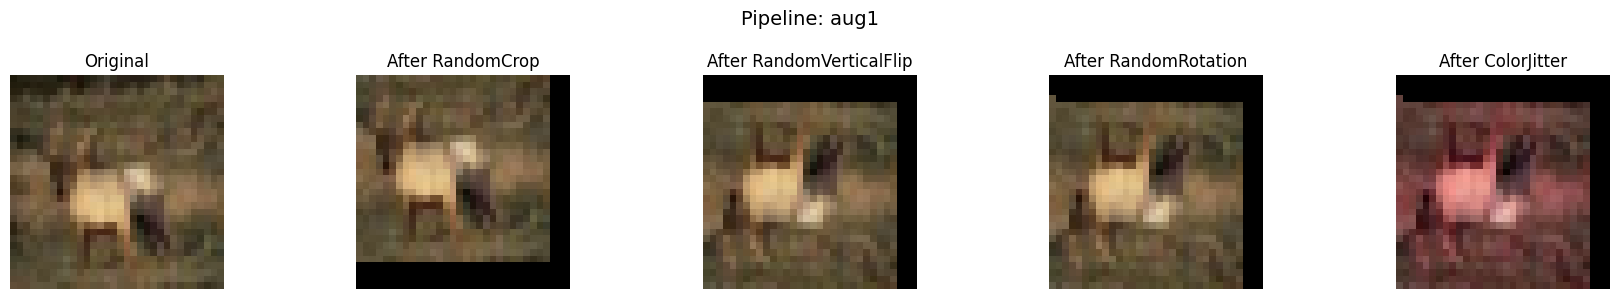

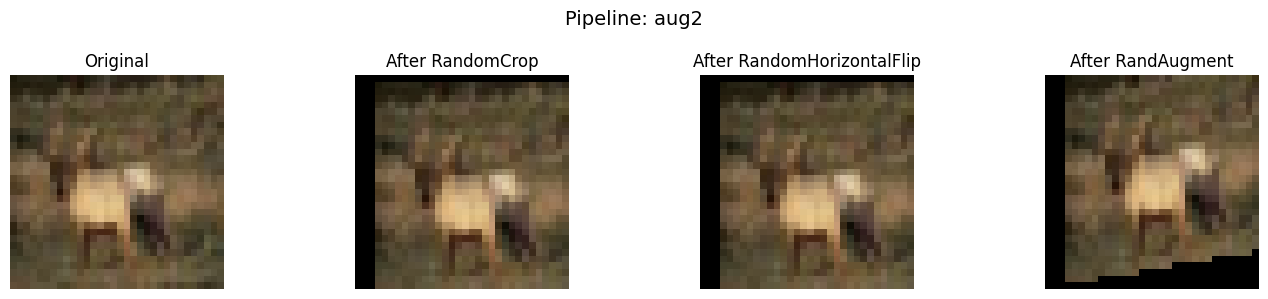

In [7]:
base_ops = [
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
]

augmentation_strategies = {
    "baseline_augmentation": v2.Compose([
        v2.ToImage(),
        v2.RandomPhotometricDistort(),
        v2.RandomGrayscale(p=0.2),
        v2.RandomInvert(p=0.2),
        *base_ops]),

    "aug1": v2.Compose([
        v2.ToImage(),
        v2.RandomCrop(32, padding=4),
        v2.RandomVerticalFlip(),
        v2.RandomRotation(degrees=20),
        v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        *base_ops
    ]),

    "aug2": v2.Compose([
        v2.ToImage(),
        v2.RandomCrop(32, padding=6),
        v2.RandomHorizontalFlip(),
        v2.RandAugment(num_ops=1, magnitude=18),
        *base_ops
    ])
}

# Safely load a single sample image from CIFAR-10 for visualization without relying on downstream cells
temp_dataset = torchvision.datasets.CIFAR10(root=cifar10data, train=True, download=True)
sample_img = Image.fromarray(temp_dataset.data[3])

def visualize_pipeline(name, pipeline, img):
    # We collect images at each step.
    # We skip ToDtype and Normalize to keep colors in uint8 range for matplotlib.
    images = [img]
    titles = ["Original"]

    current = img
    for op in pipeline.transforms:
        # Skip operations that ruin visualization
        if isinstance(op, (v2.ToDtype, v2.Normalize)):
            continue

        current = op(current)

        # We apply ToImage so the tensor conversions work, but we don't need a separate plot for it
        if not isinstance(op, v2.ToImage):
            images.append(current)
            titles.append(f"After {op.__class__.__name__}")

    fig, axes = plt.subplots(1, len(images), figsize=(3.5 * len(images), 3))
    # Ensure axes is iterable even if there's only 1 image (e.g., baseline)
    if len(images) == 1:
        axes = [axes]

    for ax, im, title in zip(axes, images, titles):
        if isinstance(im, torch.Tensor):
            im = im.permute(1, 2, 0).numpy()
        ax.imshow(im)
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(f"Pipeline: {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize all three configurations
for name, strategy in augmentation_strategies.items():
    visualize_pipeline(name, strategy, sample_img)

# Defining Three Optimizers

In [8]:
optimizers = {
    # Baseline, no change needed
    "baseline_sgd_momentum": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    # Justert start-læringsrate til en stabil verdi (0.001)
    "adam": lambda params: optim.Adam(params, lr=0.001),
    # Justert start-læringsrate til en stabil verdi (0.001)
    "adamw": lambda params: optim.AdamW(params, lr=0.001, weight_decay=0.01)
}

# Selecting Configuration

In [9]:
# Vi kommenterer ut de andre konfigurasjonene for å ta vare på dem til senere,
# og kjører kun Adam og AdamW nå slik at kun disse overskrives i CSV-en.
configurations = {
    "Baseline": {"arch": "baseline_simple_cnn", "aug": "baseline_augmentation", "opt": "baseline_sgd_momentum"},
    "MobileNetV3": {"arch": "mobilenet_v3", "aug": "baseline_augmentation", "opt": "baseline_sgd_momentum"},
    "DenseNet121": {"arch": "densenet121", "aug": "baseline_augmentation", "opt": "baseline_sgd_momentum"},
    "Aug1": {"arch": "baseline_simple_cnn", "aug": "aug1", "opt": "baseline_sgd_momentum"},
    "Aug2": {"arch": "baseline_simple_cnn", "aug": "aug2", "opt": "baseline_sgd_momentum"},
    "Adam": {"arch": "baseline_simple_cnn", "aug": "baseline_augmentation", "opt": "adam"},
    "AdamW": {"arch": "baseline_simple_cnn", "aug": "baseline_augmentation", "opt": "adamw"}
}

# Vi setter bare en initiell standard transformasjon for datasett-oppsettet
train_transform = augmentation_strategies["baseline_augmentation"]

# 1 Pre Processing

## 1.2 Seeding

In [10]:
experiment_seeds = [0, 1, 2]
small_experiment_seeds = [1]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

current_seed = experiment_seeds[0]
set_seed(current_seed)

## 1.3 CIFAR-10 Dataset

### 1.3.1 Downloading and Tranforming

In [11]:
# Transform for validation and test data (NO augmentations)
eval_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Vi setter transform=None siden run_experiment overskriver transformasjonen dynamisk
full_trainset_aug = torchvision.datasets.CIFAR10(root=cifar10data, train=True, download=False, transform=None)
full_trainset_eval = torchvision.datasets.CIFAR10(root=cifar10data, train=True, download=False, transform=eval_transform)

from sklearn.model_selection import train_test_split

# One fixed class-stratified split, shared by all configurations and seeds.
train_idx, val_idx = train_test_split(
    np.arange(len(full_trainset_aug)), test_size=0.1, random_state=42,
    stratify=full_trainset_aug.targets
)

trainset = torch.utils.data.Subset(full_trainset_aug, train_idx)    # map the training indices to the augmented data
valset = torch.utils.data.Subset(full_trainset_eval, val_idx)       # map the valuation indices to the normalized data

# The test set only uses the evaluation transform
testset = torchvision.datasets.CIFAR10(root=cifar10data, train=False, download=False, transform=eval_transform)

In [12]:
batch_size = 128

### 1.3.2 Step by Step Inspection for understanding underlying data

In [13]:
print("--Before Transformation Shape and Dtype--\n ---------------------------------------")
from PIL import Image
pimg = Image.fromarray(full_trainset_aug.data[0])
plabel = full_trainset_aug.targets[0]
print(type(pimg))
print(f"Size (W, H): {pimg.size}")
print(f"Mode: {pimg.mode}")

print("\n--After Transformation Shape and Dtype (Applying Baseline)--\n ---------------------------------------")
# Siden full_trainset_aug ikke har noen standard transformasjon nå,
# bruker vi "baseline_augmentation" manuelt her for å demonstrere resultatet
temp_transform = augmentation_strategies["baseline_augmentation"]
img_pil, label = trainset[0]
img = temp_transform(img_pil)

print(type(img))
print(f"Shape: {img.shape}")
print(f"Dtype: {img.dtype}")

step1_to_image = v2.ToImage()
step2_to_dtype = v2.ToDtype(torch.float32, scale=True)
step3_normalize = v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

img_t1 = step1_to_image(pimg)
img_t2 = step2_to_dtype(img_t1)
img_t3 = step3_normalize(img_t2)

print("\n-- Step-by-Step --")
print(f"After ToImage:   type={type(img_t1)}, shape={img_t1.shape}, dtype={img_t1.dtype}, min={img_t1.min()}, max={img_t1.max()}")
print(f"After ToDtype:   type={type(img_t2)}, shape={img_t2.shape}, dtype={img_t2.dtype}, min={img_t2.min():.2f}, max={img_t2.max():.2f}")
print(f"After Normalize: type={type(img_t3)}, shape={img_t3.shape}, dtype={img_t3.dtype}, min={img_t3.min():.2f}, max={img_t3.max():.2f}")

--Before Transformation Shape and Dtype--
 ---------------------------------------
<class 'PIL.Image.Image'>
Size (W, H): (32, 32)
Mode: RGB

--After Transformation Shape and Dtype (Applying Baseline)--
 ---------------------------------------
<class 'torchvision.tv_tensors._image.Image'>
Shape: torch.Size([3, 32, 32])
Dtype: torch.float32

-- Step-by-Step --
After ToImage:   type=<class 'torchvision.tv_tensors._image.Image'>, shape=torch.Size([3, 32, 32]), dtype=torch.uint8, min=0, max=255
After ToDtype:   type=<class 'torchvision.tv_tensors._image.Image'>, shape=torch.Size([3, 32, 32]), dtype=torch.float32, min=0.00, max=1.00
After Normalize: type=<class 'torchvision.tv_tensors._image.Image'>, shape=torch.Size([3, 32, 32]), dtype=torch.float32, min=-1.00, max=1.00


In [14]:
import csv
import json
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

device = DEVICE
epochs = 25
patience = 6
scheduler_patience = 3
lr_factor = 0.1

def run_experiment(config_name, config, seed):
    set_seed(seed)
    full_trainset_aug.transform = augmentation_strategies[config["aug"]]

    num_workers_detected = os.cpu_count() if os.cpu_count() is not None else 2

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=num_workers_detected)
    valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=num_workers_detected)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=num_workers_detected)

    model = architectures[config["arch"]]().to(device)
    optimiser = optimizers[config["opt"]](model.parameters())
    initial_lr = optimiser.param_groups[0]["lr"]
    weight_decay = optimiser.param_groups[0]["weight_decay"]
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", factor=lr_factor, patience=scheduler_patience
    )
    params = sum(param.numel() for param in model.parameters())
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    epoch_durations = []
    start = time.perf_counter()

    for epoch in range(epochs):
        epoch_start = time.perf_counter()
        model.train()
        train_loss = torch.zeros((), device=device)
        correct_train = torch.zeros((), device=device, dtype=torch.long)
        total_train = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimiser.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimiser.step()
            train_loss += loss.detach() * labels.size(0)
            total_train += labels.size(0)
            correct_train += outputs.argmax(1).eq(labels).sum()

        model.eval()
        val_loss = torch.zeros((), device=device)
        correct_val = torch.zeros((), device=device, dtype=torch.long)
        total_val = 0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels) * labels.size(0)
                total_val += labels.size(0)
                correct_val += outputs.argmax(1).eq(labels).sum()

        average_train_loss = (train_loss / total_train).item()
        average_val_loss = (val_loss / total_val).item()
        history["train_loss"].append(average_train_loss)
        history["val_loss"].append(average_val_loss)
        history["train_acc"].append(100 * correct_train.item() / total_train)
        history["val_acc"].append(100 * correct_val.item() / total_val)
        scheduler.step(average_val_loss)

        epoch_end = time.perf_counter()
        epoch_duration = epoch_end - epoch_start
        epoch_durations.append(epoch_duration)

        print(f"{config_name} seed {seed} epoch {epoch + 1}/{epochs}: "
              f"train loss {average_train_loss:.4f}, val loss {average_val_loss:.4f}, "
              f"val acc {history['val_acc'][-1]:.2f}% ({epoch_duration:.1f}s)")

        if average_val_loss < best_val_loss:
            best_val_loss = average_val_loss
            patience_counter = 0
            best_model_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    train_seconds = time.perf_counter() - start
    model.load_state_dict(best_model_state)
    model.eval()
    test_labels, test_predictions = [], []
    with torch.no_grad():
        for inputs, labels in testloader:
            outputs = model(inputs.to(device))
            test_labels.extend(labels.tolist())
            test_predictions.extend(outputs.argmax(1).cpu().tolist())

    avg_epoch_time = sum(epoch_durations) / len(epoch_durations) if epoch_durations else 0

    result = {
        "configuration": config_name, "seed": seed, **config, "params": params,
        "learning_rate": initial_lr, "weight_decay": weight_decay,
        "epochs_trained": len(history["val_loss"]), "train_seconds": round(train_seconds, 1),
        "avg_epoch_seconds": round(avg_epoch_time, 1),
        "best_val_loss": best_val_loss,
        "accuracy": 100 * accuracy_score(test_labels, test_predictions),
        "macro_f1": f1_score(test_labels, test_predictions, average="macro"),
    }
    return result, history, test_predictions

In [15]:
# Run seven configurations x three seeds; one CSV row per completed run.
results, histories, predictions = [], {}, {}
with open("results.csv", "w", newline="") as file:
    writer = None
    for config_name, config in configurations.items():
        for seed in experiment_seeds:
            result, history, test_predictions = run_experiment(config_name, config, seed)
            histories[(config_name, seed)] = history
            predictions[(config_name, seed)] = test_predictions
            results.append(result)
            if writer is None:
                writer = csv.DictWriter(file, fieldnames=[*result, "history"])
                writer.writeheader()
            writer.writerow({**result, "history": json.dumps(history)})
            file.flush()
            print(f"{config_name} seed {seed}: test acc {result['accuracy']:.2f}%, "
                  f"macro-F1 {result['macro_f1']:.3f}")

studies = {
    "Architecture": ["Baseline", "MobileNetV3", "DenseNet121"],
    "Augmentation": ["Baseline", "Aug1", "Aug2"],
    "Optimiser": ["Baseline", "Adam", "AdamW"],
}
'''
# Sample standard deviation (ddof=1), computed from three separate test evaluations.
for study, names in studies.items():
    print(f"\n{study}: configuration | parameters | accuracy (%) | macro-F1 | training seconds | avg epoch (s)")
    for name in names:
        runs = [row for row in results if row["configuration"] == name]
        accs = [row["accuracy"] for row in runs]
        f1s = [row["macro_f1"] for row in runs]
        avg_epochs = [row["avg_epoch_seconds"] for row in runs]
        print(f"{name:12} | {runs[0]['params']:>10} | "
              f"{np.mean(accs):.2f} ± {np.std(accs, ddof=1):.2f} | "
              f"{np.mean(f1s):.3f} ± {np.std(f1s, ddof=1):.3f} | "
              f"{np.mean([row['train_seconds'] for row in runs]):.1f} | "
              f"{np.mean(avg_epochs):.1f}")

# Choose representative configurations using validation loss, not test results.
mean_val_loss = {name: np.mean([row["best_val_loss"] for row in results
                                if row["configuration"] == name]) for name in configurations}
best_name = min(mean_val_loss, key=mean_val_loss.get)
worst_name = max(mean_val_loss, key=mean_val_loss.get)
for name in [best_name, worst_name]:
    print(f"\n{name}: per-class metrics and confusion matrix (representative seed {experiment_seeds[0]})")
    test_predictions = predictions[(name, experiment_seeds[0])]
    precision, recall, _, _ = precision_recall_fscore_support(
        testset.targets, test_predictions, labels=list(range(10)), zero_division=0
    )
    for class_name, p, r in zip(testset.classes, precision, recall):
        print(f"{class_name:12} precision {p:.3f}  recall {r:.3f}")
    ConfusionMatrixDisplay.from_predictions(
        testset.targets, test_predictions, display_labels=testset.classes, xticks_rotation=45
    )
    plt.title(f"{name} (seed {experiment_seeds[0]})")
    plt.show()

    history = histories[(name, experiment_seeds[0])]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for metric, ax in [("loss", axes[0]), ("acc", axes[1])]:
        ax.plot(history[f"train_{metric}"], label="Train")
        ax.plot(history[f"val_{metric}"], label="Validation")
        ax.set(xlabel="Epoch (starting at 0)", title=f"{name}: {metric}")
        ax.legend()
    plt.tight_layout()
    plt.show()

# Compare optimiser convergence using the same representative seed.
for name in studies["Optimiser"]:
    plt.plot(histories[(name, experiment_seeds[0])]["val_acc"], label=name)
plt.xlabel("Epoch (starting at 0)")
plt.ylabel("Validation accuracy (%)")
plt.legend()
plt.show()
'''

Baseline seed 0 epoch 1/25: train loss 2.0642, val loss 1.7205, val acc 37.34% (4.6s)
Baseline seed 0 epoch 2/25: train loss 1.5856, val loss 1.3620, val acc 50.50% (4.6s)
Baseline seed 0 epoch 3/25: train loss 1.3620, val loss 1.1811, val acc 58.06% (4.7s)
Baseline seed 0 epoch 4/25: train loss 1.2009, val loss 1.0575, val acc 63.08% (4.5s)
Baseline seed 0 epoch 5/25: train loss 1.0653, val loss 0.9295, val acc 67.54% (4.5s)
Baseline seed 0 epoch 6/25: train loss 0.9614, val loss 0.8874, val acc 69.42% (4.8s)
Baseline seed 0 epoch 7/25: train loss 0.8753, val loss 0.8298, val acc 70.20% (4.5s)
Baseline seed 0 epoch 8/25: train loss 0.7890, val loss 0.7737, val acc 73.38% (4.6s)
Baseline seed 0 epoch 9/25: train loss 0.7169, val loss 0.7552, val acc 73.38% (4.4s)
Baseline seed 0 epoch 10/25: train loss 0.6431, val loss 0.7282, val acc 75.08% (4.3s)
Baseline seed 0 epoch 11/25: train loss 0.5799, val loss 0.7214, val acc 75.18% (4.7s)
Baseline seed 0 epoch 12/25: train loss 0.5242, val 

'\n# Sample standard deviation (ddof=1), computed from three separate test evaluations.\nfor study, names in studies.items():\n    print(f"\n{study}: configuration | parameters | accuracy (%) | macro-F1 | training seconds | avg epoch (s)")\n    for name in names:\n        runs = [row for row in results if row["configuration"] == name]\n        accs = [row["accuracy"] for row in runs]\n        f1s = [row["macro_f1"] for row in runs]\n        avg_epochs = [row["avg_epoch_seconds"] for row in runs]\n        print(f"{name:12} | {runs[0][\'params\']:>10} | "\n              f"{np.mean(accs):.2f} ± {np.std(accs, ddof=1):.2f} | "\n              f"{np.mean(f1s):.3f} ± {np.std(f1s, ddof=1):.3f} | "\n              f"{np.mean([row[\'train_seconds\'] for row in runs]):.1f} | "\n              f"{np.mean(avg_epochs):.1f}")\n\n# Choose representative configurations using validation loss, not test results.\nmean_val_loss = {name: np.mean([row["best_val_loss"] for row in results\n                       


Architecture: configuration | parameters | accuracy (%) | macro-F1 | training seconds | avg epoch (s)
Baseline     |    4702582 | 75.18 ± 0.20 | 0.752 ± 0.002 | 84.7 | 4.4
MobileNetV3  |    4214842 | 76.40 ± 0.46 | 0.765 ± 0.005 | 219.9 | 12.0
DenseNet121  |    6956426 | 84.44 ± 0.48 | 0.844 ± 0.005 | 576.8 | 29.3

Augmentation: configuration | parameters | accuracy (%) | macro-F1 | training seconds | avg epoch (s)
Baseline     |    4702582 | 75.18 ± 0.20 | 0.752 ± 0.002 | 84.7 | 4.4
Aug1         |    4702582 | 69.80 ± 0.29 | 0.692 ± 0.005 | 366.7 | 14.7
Aug2         |    4702582 | 75.63 ± 0.75 | 0.753 ± 0.008 | 171.4 | 6.8

Optimiser: configuration | parameters | accuracy (%) | macro-F1 | training seconds | avg epoch (s)
Baseline     |    4702582 | 75.18 ± 0.20 | 0.752 ± 0.002 | 84.7 | 4.4
Adam         |    4702582 | 76.49 ± 0.08 | 0.762 ± 0.002 | 58.4 | 4.1
AdamW        |    4702582 | 76.42 ± 0.43 | 0.763 ± 0.006 | 61.1 | 4.1

DenseNet121: per-class metrics and confusion matrix (rep

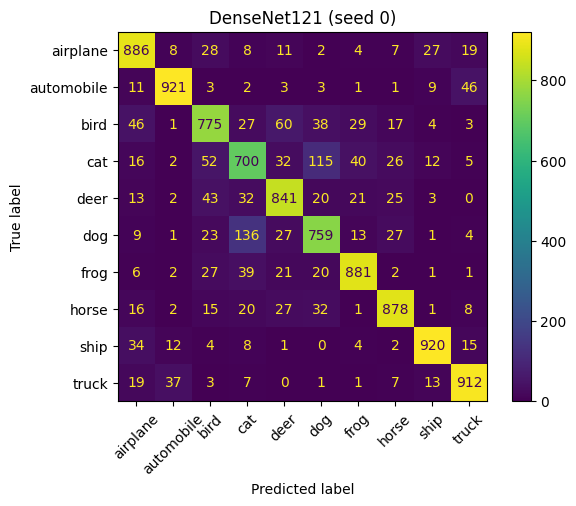

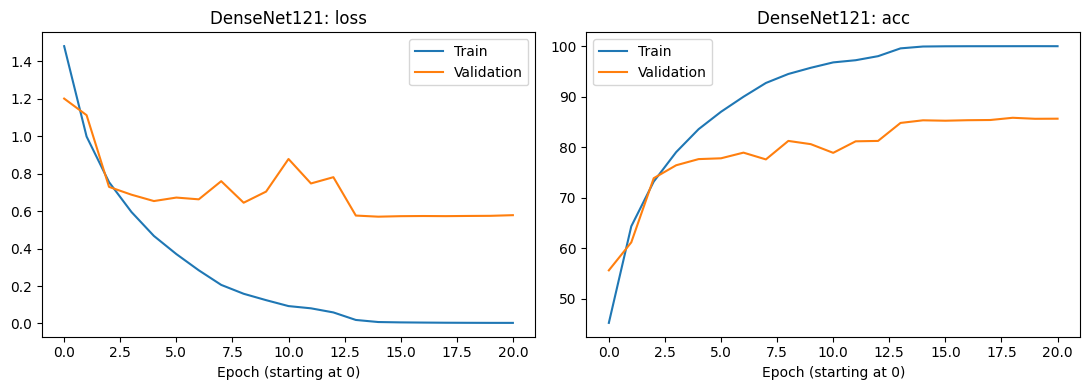


Aug1: per-class metrics and confusion matrix (representative seed 0)
airplane     precision 0.700  recall 0.780
automobile   precision 0.752  recall 0.892
bird         precision 0.626  recall 0.513
cat          precision 0.501  recall 0.498
deer         precision 0.708  recall 0.595
dog          precision 0.659  recall 0.600
frog         precision 0.774  recall 0.795
horse        precision 0.698  recall 0.776
ship         precision 0.837  recall 0.742
truck        precision 0.738  recall 0.819


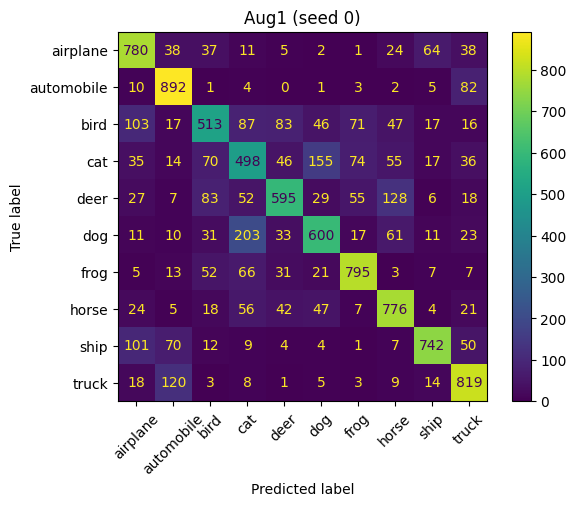

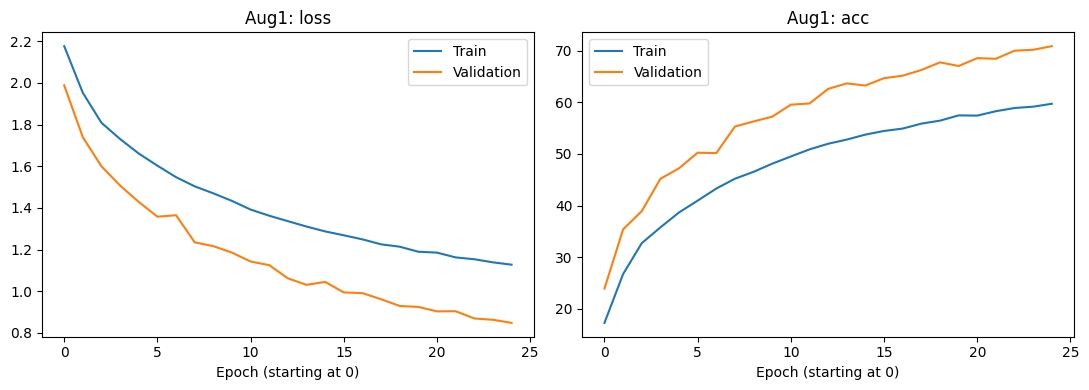

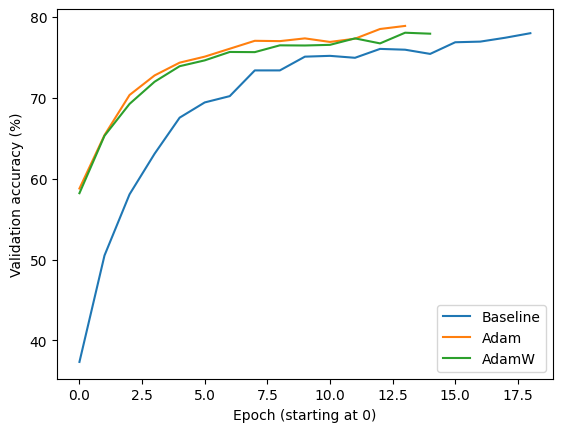

In [16]:
# Sample standard deviation (ddof=1), computed from three separate test evaluations.
for study, names in studies.items():
    print(f"\n{study}: configuration | parameters | accuracy (%) | macro-F1 | training seconds | avg epoch (s)")
    for name in names:
        runs = [row for row in results if row["configuration"] == name]
        accs = [row["accuracy"] for row in runs]
        f1s = [row["macro_f1"] for row in runs]
        avg_epochs = [row["avg_epoch_seconds"] for row in runs]
        print(f"{name:12} | {runs[0]['params']:>10} | "
              f"{np.mean(accs):.2f} ± {np.std(accs, ddof=1):.2f} | "
              f"{np.mean(f1s):.3f} ± {np.std(f1s, ddof=1):.3f} | "
              f"{np.mean([row['train_seconds'] for row in runs]):.1f} | "
              f"{np.mean(avg_epochs):.1f}")

# Choose representative configurations using validation loss, not test results.
mean_val_loss = {name: np.mean([row["best_val_loss"] for row in results
                                if row["configuration"] == name]) for name in configurations}
best_name = min(mean_val_loss, key=mean_val_loss.get)
worst_name = max(mean_val_loss, key=mean_val_loss.get)
for name in [best_name, worst_name]:
    print(f"\n{name}: per-class metrics and confusion matrix (representative seed {experiment_seeds[0]})")
    test_predictions = predictions[(name, experiment_seeds[0])]
    precision, recall, _, _ = precision_recall_fscore_support(
        testset.targets, test_predictions, labels=list(range(10)), zero_division=0
    )
    for class_name, p, r in zip(testset.classes, precision, recall):
        print(f"{class_name:12} precision {p:.3f}  recall {r:.3f}")
    ConfusionMatrixDisplay.from_predictions(
        testset.targets, test_predictions, display_labels=testset.classes, xticks_rotation=45
    )
    plt.title(f"{name} (seed {experiment_seeds[0]})")
    plt.show()

    history = histories[(name, experiment_seeds[0])]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for metric, ax in [("loss", axes[0]), ("acc", axes[1])]:
        ax.plot(history[f"train_{metric}"], label="Train")
        ax.plot(history[f"val_{metric}"], label="Validation")
        ax.set(xlabel="Epoch (starting at 0)", title=f"{name}: {metric}")
        ax.legend()
    plt.tight_layout()
    plt.show()

# Compare optimiser convergence using the same representative seed.
for name in studies["Optimiser"]:
    plt.plot(histories[(name, experiment_seeds[0])]["val_acc"], label=name)
plt.xlabel("Epoch (starting at 0)")
plt.ylabel("Validation accuracy (%)")
plt.legend()
plt.show()